In [1]:
import pandas as pd
import numpy as np 
import nltk 
from gensim.models import word2vec
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy 


In [2]:
review_data = pd.read_csv('../data/processed_data/drugsComTrain_text_preprocessing.csv')

In [3]:
review_data.head()

,Unnamed: 0,Unnamed: 0.1,drug_id,drugName,condition,review,rating,date,usefulCount,lowered_review,...,stemmed_review,lemmatized_review,review_len,stemmed_review_len,lem_review_len,word_count,sentiment_vader,sentiment_vader_label,sentiment_textblob,sentiment_textblob_label
0,0,0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,2012-05-20,27,"""it has no side effect, i take it in combinati...",...,no side effect take combin bystol mg fish oil,no side effect take combin bystol mg fish oil,46,45,45,9,-0.2960,Negative,0.000000,neutral
1,1,1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,2010-04-27,192,"""my son is halfway through his fourth week of ...",...,son halfway fourth week intuniv becam concern ...,son halfway fourth week intuniv becam concern ...,372,369,367,65,0.6929,Positive,0.114583,positive
2,2,2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,2009-12-14,17,"""i used to take another oral contraceptive, wh...",...,use take anoth oral contracept pill cycl happi...,use take anoth oral contracept pill cycl happi...,403,401,401,70,0.2732,Positive,0.105000,positive
3,3,3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,2015-11-03,10,"""this is my first time using any form of birth...",...,first time use form birth control glad went pa...,first time use form birth control glad went pa...,226,223,225,39,0.1027,Positive,0.300000,positive
4,4,4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,2016-11-27,37,"""suboxone has completely turned my life around...",...,suboxon complet turn life around feel healthie...,suboxon complet turn life around feel healthie...,380,378,379,58,0.8934,Positive,0.147037,positive


In [4]:
column_names=['sentiment_vader_label','sentiment_textblob_label','stopwords_remove_review','drug_id','drugName','condition','rating']
review_data_new = review_data[column_names]



In [5]:
review_data_new.head()

,sentiment_vader_label,sentiment_textblob_label,stopwords_remove_review,drug_id,drugName,condition,rating
0,Negative,neutral,no side effect take combin bystol mg fish oil,206461,Valsartan,Left Ventricular Dysfunction,9.0
1,Positive,positive,son halfway fourth week intuniv becam concern ...,95260,Guanfacine,ADHD,8.0
2,Positive,positive,use take anoth oral contracept pill cycl happi...,92703,Lybrel,Birth Control,5.0
3,Positive,positive,first time use form birth control glad went pa...,138000,Ortho Evra,Birth Control,8.0
4,Positive,positive,suboxon complet turn life around feel healthie...,35696,Buprenorphine / naloxone,Opiate Dependence,9.0


Word Embeddings:

Tf_idf 

In [6]:
tf_idf = TfidfVectorizer()

In [7]:
tfidf_matrix = tf_idf.fit_transform(review_data_new['stopwords_remove_review'])

In [8]:
tfidf_matrix.get_shape()

(160392, 55625)

In [9]:
feature_names = tf_idf.get_feature_names_out()

CLASSIFICATION USING MACHINE LEARNING AND DEEP LEARNING

Ensemble learning 

Using TextBlob label:

In [10]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt 
import seaborn as sns

In [11]:
x=tfidf_matrix
y1=review_data_new['sentiment_textblob_label']


In [12]:
# spliting of train and test data for each of the sentiment analyzer : 
# tf_idf & y1(textblob label): 
X1_train, X1_test, y1_train, y1_test = train_test_split(x, y1, test_size=0.2, shuffle=True)



In [13]:
svc = LinearSVC()
lr = LogisticRegression()

In [14]:
Text_blob_model_svc=svc.fit(X1_train,y1_train)
Text_blob_model_lr=lr.fit(X1_train,y1_train)


c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
y1_pred_svc= Text_blob_model_svc.predict(X1_test)
y1_pred_lr = Text_blob_model_lr.predict(X1_test)

In [16]:
#Combine predictions using voting
voting_classifier = VotingClassifier(estimators=[('logistic_regression', lr),('svm', svc)], voting='hard')  
# Use 'soft' for soft voting - here the average probability is considered for decision making - doesnt work since linear svc doesnot have predict_proba
# use hard voting - Each model gets one vote, and the majority class prediction becomes the final prediction. In case of a tie, you can break it arbitrarily or by using some rule.


In [17]:
voting_classifier.fit(X1_train, y1_train)


c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


VotingClassifier(estimators=[('logistic_regression', LogisticRegression()),
                             ('svm', LinearSVC())])

In [18]:
ensemble_pred_textblob = voting_classifier.predict(X1_test)

In [19]:
conf_textblob= confusion_matrix(y1_test, ensemble_pred_textblob)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_textblob, display_labels = [False, True])

In [20]:
accuracy_textblob =  metrics.accuracy_score(y1_test,ensemble_pred_textblob)
print(accuracy_textblob)

0.9623741388447271


In [21]:
#confusion matrix metrics
print(classification_report(y1_test,ensemble_pred_textblob))

              precision    recall  f1-score   support

    negative       0.94      0.94      0.94      8611
     neutral       0.96      0.95      0.96      3290
    positive       0.97      0.97      0.97     20178

    accuracy                           0.96     32079
   macro avg       0.96      0.96      0.96     32079
weighted avg       0.96      0.96      0.96     32079



In [22]:
labels = ['positive','negative','neutral']

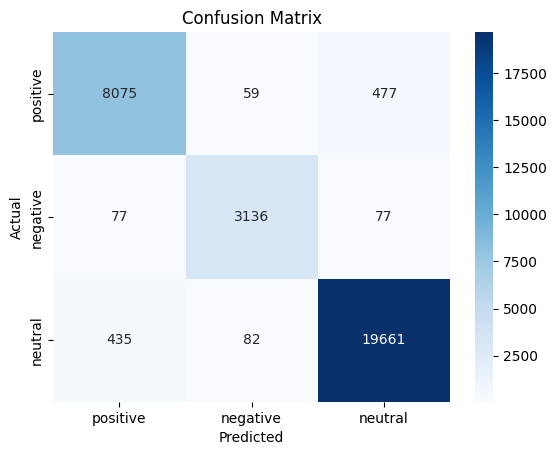

In [23]:
sns.heatmap(conf_textblob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Using Vader Label:

In [24]:
y2=review_data_new['sentiment_vader_label']
x=tfidf_matrix

In [25]:
# tf_idf & y2(vader label):
X2_train, X2_test, y2_train, y2_test = train_test_split(x, y2, test_size=0.2, shuffle=True)

In [26]:
vader_model_svc = svc.fit(X2_train,y2_train)
vader_model_lr = lr.fit(X2_train,y2_train)


c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
vader_pred_svc= vader_model_svc.predict(X2_test)
vader_pred_lr= vader_model_lr.predict(X2_test)

In [28]:
#Combine predictions using voting
voting_classifier = VotingClassifier(estimators=[('logistic_regression', lr),('svm', svc)], voting='hard')  
# Use 'soft' for soft voting - here the average probability is considered for decision making - doesnt work since linear svc doesnot have predict_proba
# use hard voting - Each model gets one vote, and the majority class prediction becomes the final prediction. In case of a tie, you can break it arbitrarily or by using some rule.


In [29]:
voting_classifier.fit(X2_train, y2_train)


c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


VotingClassifier(estimators=[('logistic_regression', LogisticRegression()),
                             ('svm', LinearSVC())])

In [30]:
ensemble_pred_vader = voting_classifier.predict(X2_test)

In [31]:
conf_vader = confusion_matrix(y2_test, ensemble_pred_vader)
cm_display_vader = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_vader, display_labels = [False, True])

In [32]:
accuracy_vader =  metrics.accuracy_score(y2_test,ensemble_pred_vader)
print(accuracy_vader)

0.9245612394401321


In [33]:
#confusion matrix metrics
print(classification_report(y2_test, ensemble_pred_vader))

              precision    recall  f1-score   support

    Negative       0.91      0.96      0.93     14700
     Neutral       0.94      0.50      0.66      1962
    Positive       0.94      0.94      0.94     15417

    accuracy                           0.92     32079
   macro avg       0.93      0.80      0.84     32079
weighted avg       0.93      0.92      0.92     32079



In [34]:
labels_vader = ['Positive','Negative','Neutral']

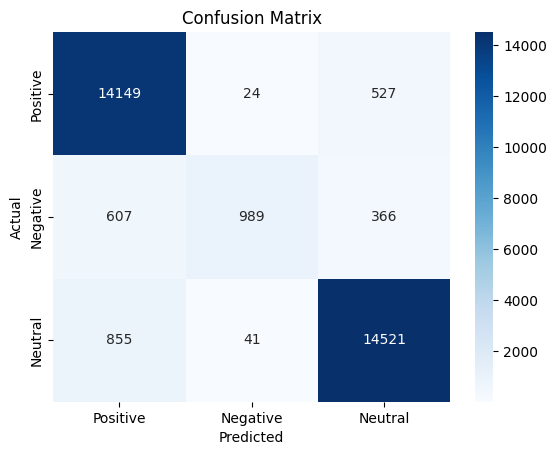

In [35]:
sns.heatmap(conf_vader, annot=True, fmt='d', cmap='Blues', xticklabels=labels_vader, yticklabels=labels_vader)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()